In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from infomap import Infomap
import pickle
from collections import defaultdict
import sys
sys.path.insert(1, '../')
from Harmonic_degree import *

In [7]:
# Open data
with open("GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "rb") as f:
    data_1 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_2/data_2.pkl", "rb") as f:
   data_2 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_3/data_3.pkl", "rb") as f:
    data_3 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_4/data_4.pkl", "rb") as f:
    data_4 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_5/data_5.pkl", "rb") as f:
    data_5 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_6/data_6.pkl", "rb") as f:
    data_6 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_7/data_7.pkl", "rb") as f:
    data_7 = pickle.load(f)

print( len(data_1) +len(data_2) + len(data_3) + len(data_4)+ len(data_5) + len(data_6) + len(data_7))  

data ={}
for name, g in data_1.items():
    data[name] = g

for name, g in data_2.items():
    data[name] = g

for name, g in data_3.items():
    data[name] = g
    
for name, g in data_4.items():
    data[name] = g
    
for name, g in data_5.items():
    data[name] = g

for name, g in data_6.items():
    data[name] = g

for name, g in data_7.items():
    data[name] = g
print(len(data))

50
50


In [3]:
data.keys()

dict_keys(['E-road', 'NetSci Collab', 'C. Elegans', 'Song of Ice and Fire', 'Emails', 'Facebook', 'basophil', 'brain', 'cardiac_muscle', 'cornea', 'epidermis', 'jejunum', 'locus_ceruleus', 'lung', 'natural_killer_cell', 'neuron', 'ovarian_follicle', 't_lymphocyte', 'Relativity collab', 'Oregon route-views', 'Lastfm Asia', 'Power: US Grid', 'Power: Eris', 'Animal net: Weaver', 'Animal net: Tortoise', 'Bio: plant', 'Bio: worm', 'Bio: yeast', 'Tech: PGP', 'Flights', 'Power: bcspwr09', 'Power: bcspwr10', 'Minnesota Road', 'Tech: Routers rf', 'Tech: WHOIS', 'Web: edu', 'Web: polblogs', 'FB: Gov.', 'Hamsterster', 'FB: USFCA72', 'FB: UC64', 'FB: Haverford76', 'FB: Colgate88', 'FB: American75', 'Anybeat', 'Erdos Collab', 'CS Collab', 'Web: Indochina', 'Web: EPA', 'Web: spam'])

In [4]:
# Load sbm
with open("GT_Tools_producing_data/Intermediate_outputs_1/sbm_1.pkl", "rb") as f:
    sbm_1 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_2/sbm_2.pkl", "rb") as f:
    sbm_2 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_3/sbm_3.pkl", "rb") as f:
    sbm_3 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_4/sbm_4.pkl", "rb") as f:
    sbm_4 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_5/sbm_5.pkl", "rb") as f:
    sbm_5 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_6/sbm_6.pkl", "rb") as f:
    sbm_6 = pickle.load(f)

with open("GT_Tools_producing_data/Intermediate_outputs_7/sbm_7.pkl", "rb") as f:
    sbm_7 = pickle.load(f)

sbm ={}
for name, g in sbm_1.items():
    sbm[name] = g

for name, g in sbm_2.items():
    sbm[name] = g

for name, g in sbm_3.items():
    sbm[name] = g
    
for name, g in sbm_4.items():
    sbm[name] = g
    
for name, g in sbm_5.items():
    sbm[name] = g

for name, g in sbm_6.items():
    sbm[name] = g

for name, g in sbm_7.items():
    sbm[name] = g

print(len(sbm))

50


In [5]:
sbm.keys()

dict_keys(['E-road', 'NetSci Collab', 'C. Elegans', 'Song of Ice and Fire', 'Emails', 'Facebook', 'basophil', 'brain', 'cardiac_muscle', 'cornea', 'epidermis', 'jejunum', 'locus_ceruleus', 'lung', 'natural_killer_cell', 'neuron', 'ovarian_follicle', 't_lymphocyte', 'Relativity collab', 'Oregon route-views', 'Lastfm Asia', 'Power: US Grid', 'Power: Eris', 'Animal net: Weaver', 'Animal net: Tortoise', 'Bio: plant', 'Bio: worm', 'Bio: yeast', 'Tech: PGP', 'Flights', 'Power: bcspwr09', 'Power: bcspwr10', 'Minnesota Road', 'Tech: Routers rf', 'Tech: WHOIS', 'Web: edu', 'Web: polblogs', 'FB: Gov.', 'Hamsterster', 'FB: USFCA72', 'FB: UC64', 'FB: Haverford76', 'FB: Colgate88', 'FB: American75', 'Anybeat', 'Erdos Collab', 'CS Collab', 'Web: Indochina', 'Web: EPA', 'Web: spam'])

# CS Collab, Greedy mod

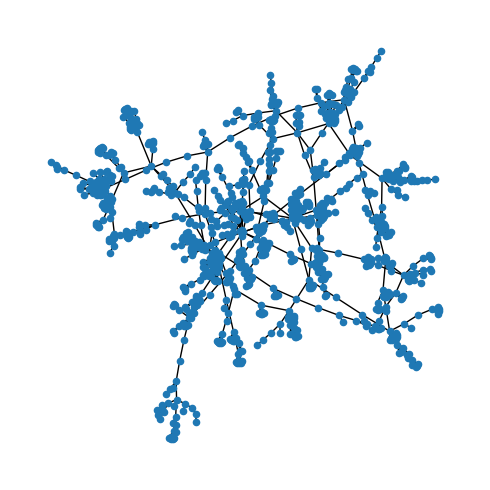

In [7]:
Ag=data["CS Collab"]
pos=nx.spring_layout(Ag,iterations=100)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False, node_size=20)
plt.tight_layout()
A = nx.adjacency_matrix(Ag)

       H   Mod. H   Var. H  CF  Mod. CF  Var. CF
0.961951 0.964021 0.017051 0.0      0.0 1.299261


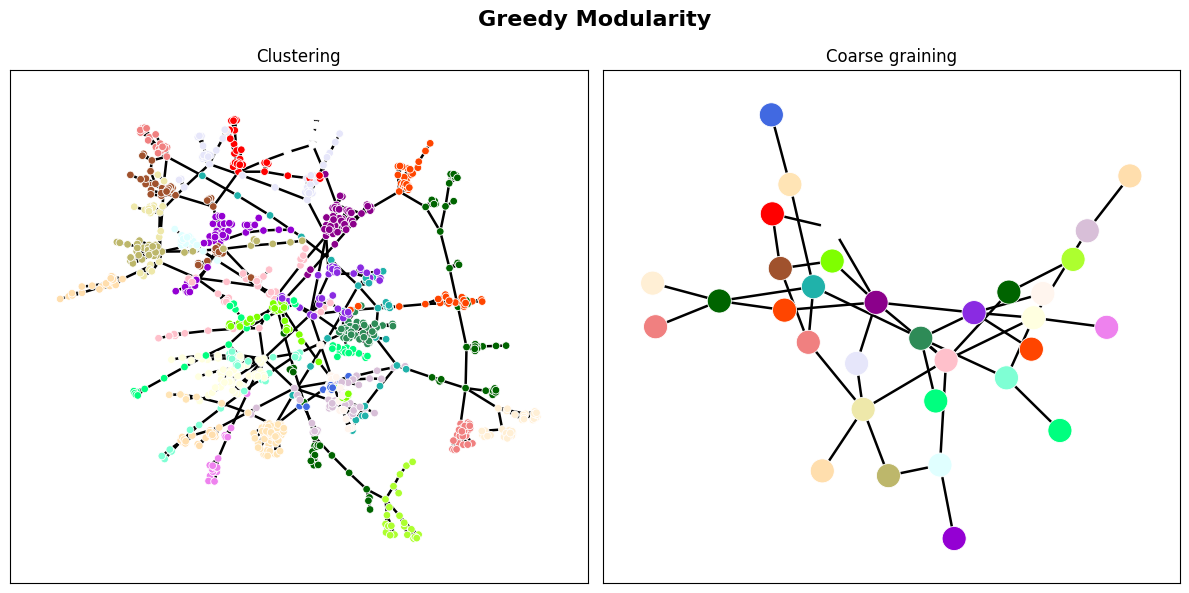

In [49]:
# Greedy Mod
nw = nx.community.greedy_modularity_communities(Ag)
clusters = {}  # Initialize empty dictionary
# Iterate over the detected communities and assign cluster labels
for cluster_id, cluster_nodes in enumerate(nw):
    for node in cluster_nodes:
        clusters[node] = cluster_id  # Assign cluster ID to node
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Greedy Modularity", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("CS_Collab_greedy_mod.pdf")

# FB Haverford, Louvain

In [45]:
Ag = data["FB: Haverford76"]

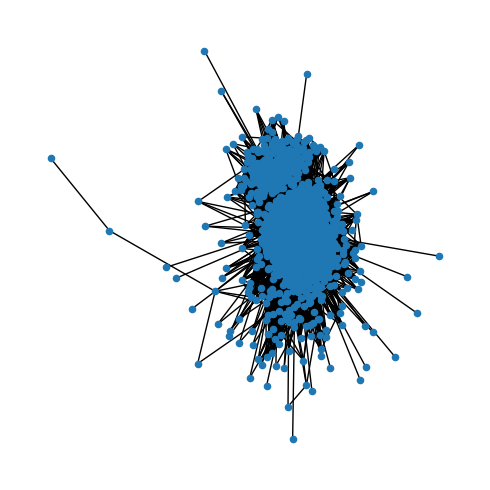

In [22]:
pos=nx.spring_layout(Ag,iterations=100)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False, node_size=20)
plt.tight_layout()

       H   Mod. H   Var. H  CF  Mod. CF   Var. CF
0.036653 0.035999 7.246029 0.0      0.0 17.552191


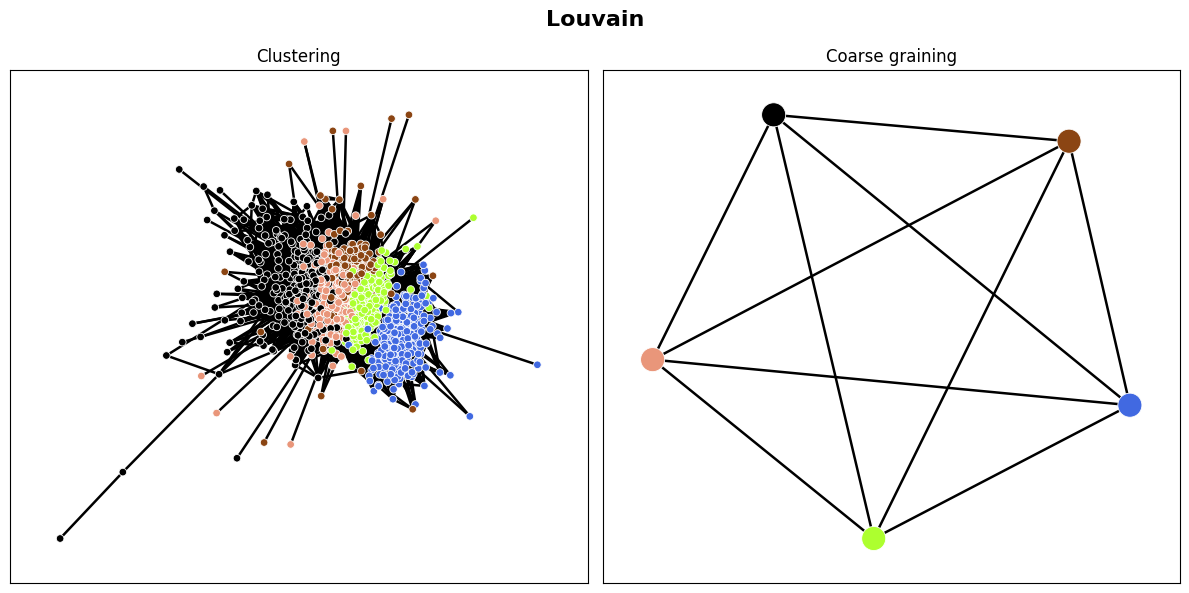

In [47]:
# Louvain
lv = nx.community.louvain_communities(Ag)
clusters = {}  # Initialize empty dictionary
# Iterate over the detected communities and assign cluster labels
for cluster_id, cluster_nodes in enumerate(lv):
    for node in cluster_nodes:
        clusters[node] = cluster_id  # Assign cluster ID to node
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Louvain", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("Haverford_Louv.pdf")

# Web: edu, Label Prop

In [34]:
Ag = data["Web: edu"]
print(len(Ag.nodes()))
print(len(Ag.edges()))

3031
6474


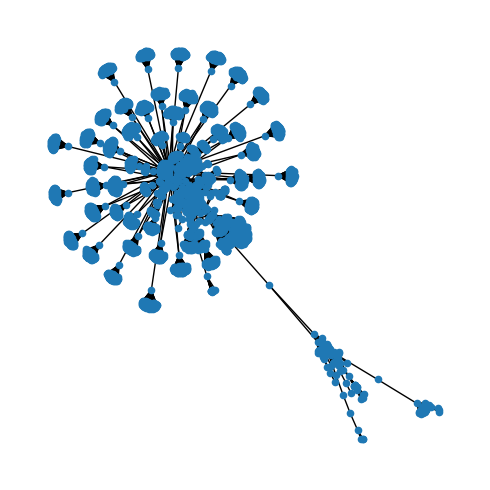

In [61]:
Ag=data["Web: edu"]
pos=nx.spring_layout(Ag,iterations=200)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False, node_size=20)
plt.tight_layout()

       H   Mod. H  Var. H  CF  Mod. CF  Var. CF
0.985153 0.959778 0.00544 0.0      0.0 2.202806


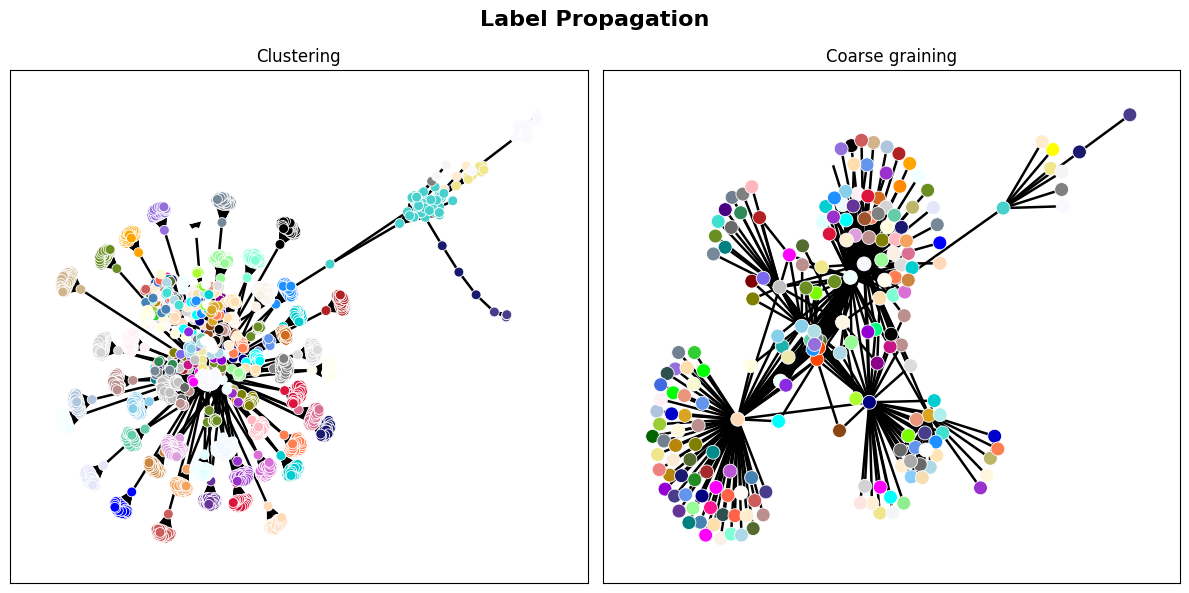

In [41]:
# label propagation
lb = nx.community.label_propagation_communities(Ag)
clusters = {}  # Initialize empty dictionary
# Iterate over the detected communities and assign cluster labels
for cluster_id, cluster_nodes in enumerate(lb):
    for node in cluster_nodes:
        clusters[node] = cluster_id  # Assign cluster ID to node
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 100)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Label Propagation", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("Web_edu_lab_prop.pdf")

# Power bcspwr09, SBM

In [42]:
Ag = data["Power: bcspwr09"]
print(len(Ag.nodes()))
print(len(Ag.edges()))

1723
2394


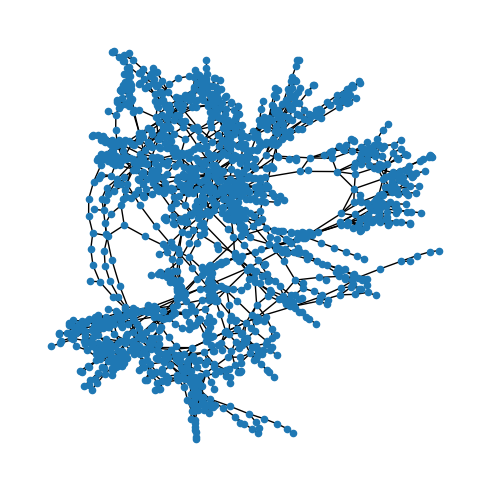

In [53]:
Ag= data["Power: bcspwr09"]
pos=nx.spring_layout(Ag,iterations=200)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False, node_size=20)
plt.tight_layout()

       H   Mod. H   Var. H  CF  Mod. CF  Var. CF
0.952409 0.950977 0.023022 0.0      0.0 1.516008


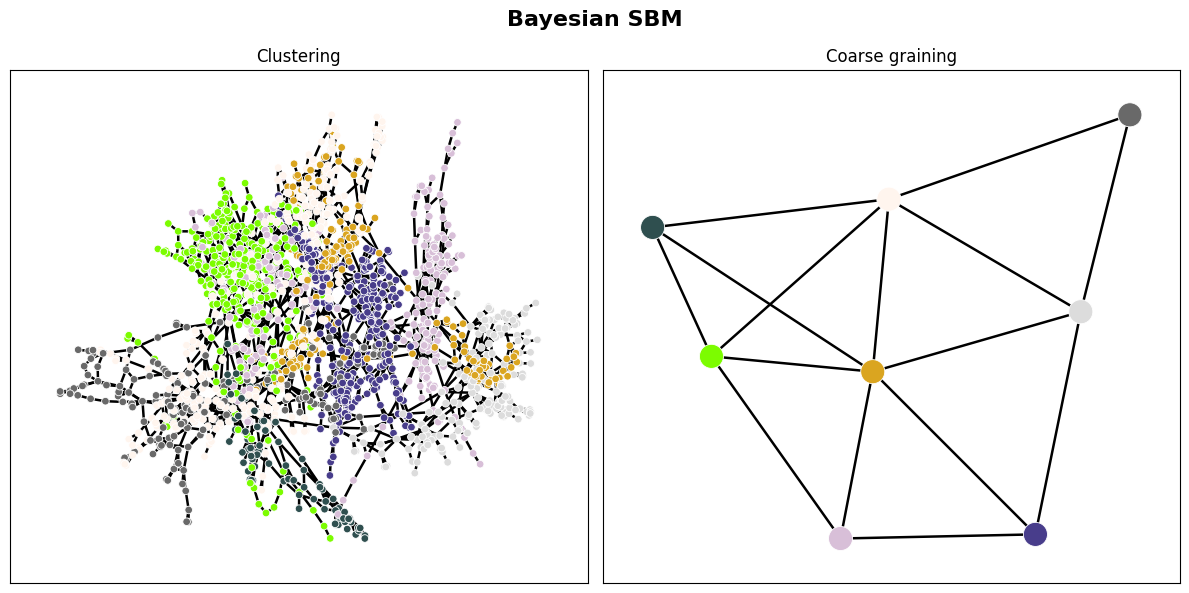

In [44]:
# Bayesian SBM
clusters = sbm["Power: bcspwr09"]
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Bayesian SBM", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("Power_bcspwr09_BSBM.pdf")

# C. Elegans, Greedy Mod

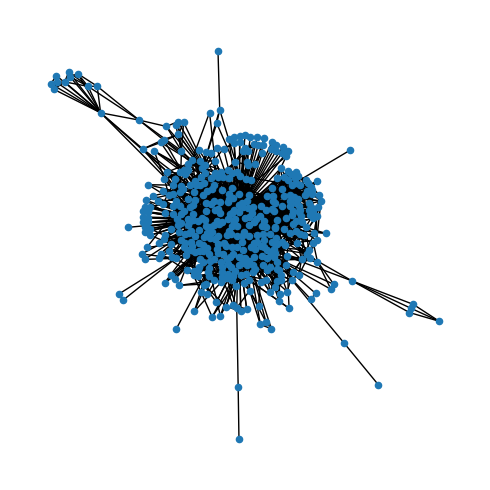

In [6]:
Ag=data["C. Elegans"]
pos=nx.spring_layout(Ag,iterations=200)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False, node_size=20)
plt.tight_layout()

       H   Mod. H   Var. H  CF  Mod. CF  Var. CF
0.350993 0.381894 0.563849 0.0      0.0  2.21977


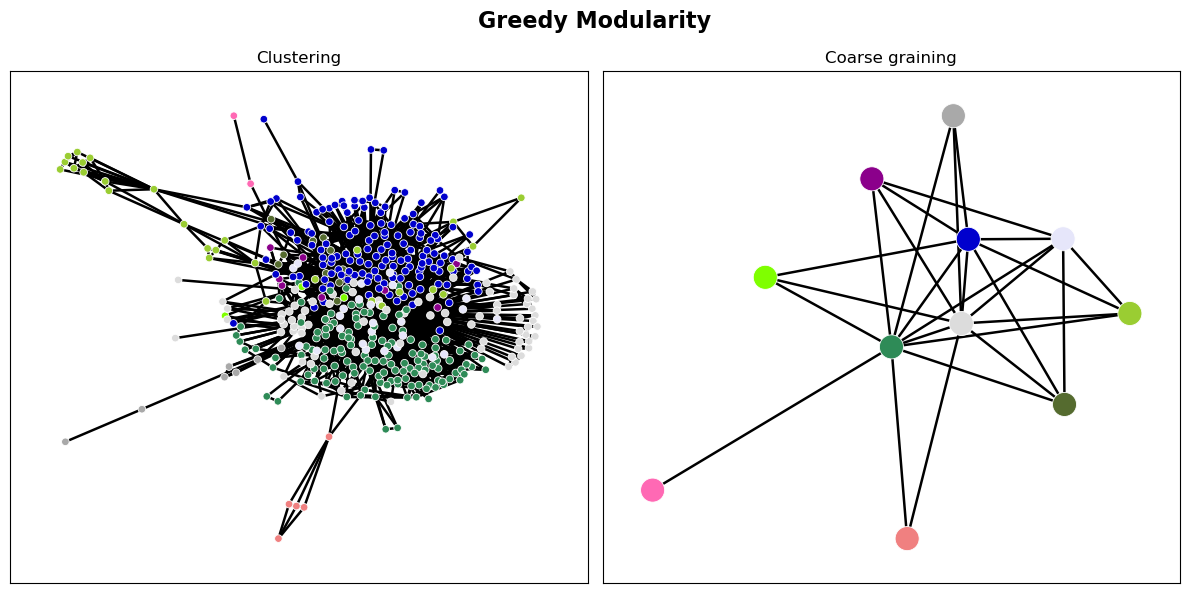

In [7]:
# Greedy modularity
nw = nx.community.greedy_modularity_communities(Ag)
clusters = {}  # Initialize empty dictionary
# Iterate over the detected communities and assign cluster labels
for cluster_id, cluster_nodes in enumerate(nw):
    for node in cluster_nodes:
        clusters[node] = cluster_id  # Assign cluster ID to node
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Greedy Modularity", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("C_Elegans_Mod.pdf")

# Facebook, Infomap

2888
2981


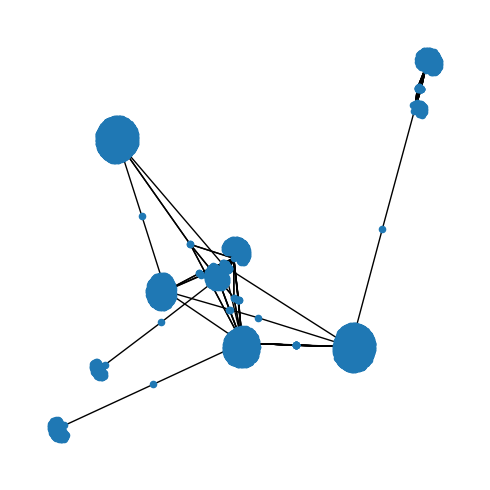

In [8]:
Ag = data["Facebook"]
print(len(Ag.nodes()))
print(len(Ag.edges()))
Ag=data["Facebook"]
pos=nx.spring_layout(Ag,iterations=200)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False, node_size=20)
plt.tight_layout()

       H   Mod. H   Var. H       CF  Mod. CF  Var. CF
0.982341 0.985284 0.010427 0.005194    0.625 0.995265


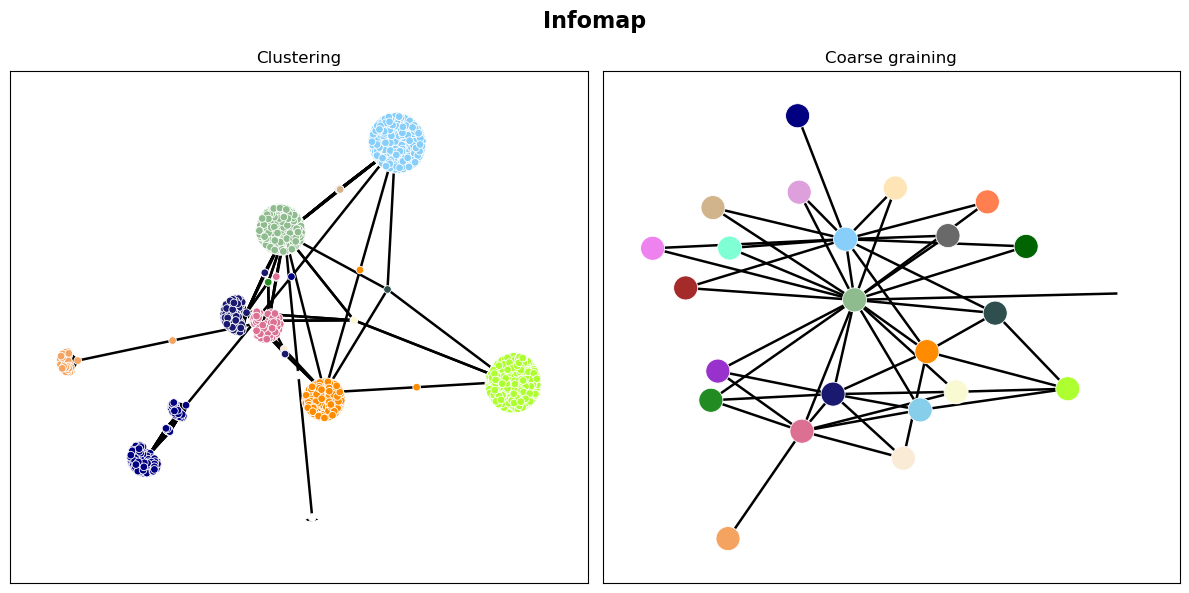

In [11]:
# Infomap
im= Infomap(two_level=True,silent=True, num_trials=20)
im.add_networkx_graph(Ag)
im.run()
clusters = im.get_modules()
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 30)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Infomap", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))
#f.savefig("FB_infomap.pdf")